# Bi-Cross-Validation Evaluation — Reaching

Evaluate 5-fold BCV on the reaching dataset (M1 + PMd).  
Uses `evaluate_trial_average` with a configurable regressor (`"linear"` or `"mlp"`).  
Set the config variables in the next cell to match the trained model.

In [1]:
import os, sys, importlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

import msca, msca.models, msca.architectures, msca.utils, msca.evaluations
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca.evaluations)
importlib.reload(msca)
from msca import mSCA
from msca.evaluations import evaluate_trial_average

/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/torch/utils/_contextlib.py:125: UserWarning: Decorating classes is deprecated and will be disabled in future versions. You should only decorate functions or methods. To preserve the current behavior of class decoration, you can directly decorate the `__init__` method and nothing else.
  warnings.warn("Decorating classes is deprecated and will be disabled in "


## Config
Change these to match the model you want to evaluate.

In [2]:
# ── Model type ──────────────────────────────────────────────────────────────
LOSS_FUNC    = "Poisson"     # "Poisson" for reaching (binned spikes)
DECODER_TYPE = "nonlinear"   # "linear" or "nonlinear"
REGRESSOR    = "linear"      # regressor used to predict held-out neurons: "linear" or "mlp"

# ── Paths ───────────────────────────────────────────────────────────────────
EXPERIMENT_PATH = "./results/bi-cross-validation/nonlinear-nonlinear/"

# ── mSCA kwargs — must match the trained model exactly ──────────────────────
MSCA_KWARGS = dict(
    n_components        = 20,
    loss_func           = LOSS_FUNC,
    n_epochs            = 5000,
    post_hoc_epoch      = -1,
    linear              = False,          # nonlinear encoder
    lam_region          = 0.0,
    decoder_type        = DECODER_TYPE,
    decoder_hidden_size = 40,             # ignored if decoder_type="linear"
    decoder_activation  = "tanh",        # ignored if decoder_type="linear"
    cd_rate             = 0.5,
    cd_mode             = "both",
    filter_len          = 41,
    init                = "unique",
    decoder_init_mode   = "pca",
    sparsity_warmup_epochs = 1000,
    balance_interval    = 1000,
)

## 1. Load reaching data

In [3]:
data = torch.load("./data/x_target_aligned.pt", weights_only=False)

X = {
    "M1":  [x.astype("float32") for x in data["M1"]],
    "PMd": [x.astype("float32") for x in data["PMd"]],
}

print(f"M1:  {len(X['M1'])} trials, {X['M1'][0].shape[1]} neurons")
print(f"PMd: {len(X['PMd'])} trials, {X['PMd'][0].shape[1]} neurons")

M1:  222 trials, 84 neurons
PMd: 222 trials, 210 neurons


## 2. Load neuron splits

In [4]:
train_idxs = torch.load(os.path.join(EXPERIMENT_PATH, "n_train_splits.pt"), weights_only=False)
test_idxs  = torch.load(os.path.join(EXPERIMENT_PATH, "n_test_splits.pt"),  weights_only=False)

n_folds = len(train_idxs[list(train_idxs.keys())[0]])
print(f"Number of folds: {n_folds}")
for k in train_idxs:
    print(f"  {k}: train={[len(t) for t in train_idxs[k]]}, test={[len(t) for t in test_idxs[k]]}")

Number of folds: 5
  M1: train=[67, 67, 67, 67, 68], test=[17, 17, 17, 17, 16]
  PMd: train=[168, 168, 168, 168, 168], test=[42, 42, 42, 42, 42]


## 3. Evaluate — `evaluate_trial_average`

For each neuron-fold `i`:
1. Load `msca_split_{i}.pt` (trained on training neurons)
2. Call `evaluate_trial_average(msca, X_train, X_val, regressor=REGRESSOR)` which:
   - Infers latents Z from training neurons
   - KFold splits across trials: fits `REGRESSOR` (Z → X_val) on train trials, predicts test trials
3. Compute variance-weighted R² from the returned predictions

In [5]:
all_fold_r2 = []   # one scalar R² per neuron-fold
LOSS_FUNC    = "Poisson"     # "Poisson" for reaching (binned spikes)
DECODER_TYPE = "nonlinear"   # "linear" or "nonlinear"
REGRESSOR    = "linear"      # regressor used to predict held-out neurons: "linear" or "mlp"

for i in range(n_folds):
    print(f"\n--- Fold {i} ---")

    X_train = {k: [trial[:, train_idxs[k][i]] for trial in v] for k, v in X.items()}
    X_val   = {k: [trial[:, test_idxs[k][i]]  for trial in v] for k, v in X.items()}

    model_path = os.path.join(EXPERIMENT_PATH, f"msca_split_{i}.pt")
    model = mSCA(
            n_components        = 20,
            loss_func           = LOSS_FUNC,
            n_epochs            = 5000,
            post_hoc_epoch      = -1,
            linear              = False,          # nonlinear encoder
            lam_region          = 0.0,
            decoder_type        = DECODER_TYPE,
            decoder_hidden_size = 40,             # ignored if decoder_type="linear"
            decoder_activation  = "tanh",        # ignored if decoder_type="linear"
            cd_rate             = 0.5,
            cd_mode             = "both",
            filter_len          = 41,
            init                = "unique",
            decoder_init_mode   = "pca",
            sparsity_warmup_epochs = 1000,
            balance_interval    = 1000,
        )
    model.load(model_path, X_train)
    print(f"  Loaded: {model_path}")

    # Returns {region: [pred_trial_0, pred_trial_1, ...]}
    predictions = evaluate_trial_average(model, X_train, X_val,loss_func="Poisson", regressor=REGRESSOR, n_splits=5)

    # Compute variance-weighted R² across regions
    r2_per_region = {}
    for k in X_val:
        y_true = np.concatenate([t[model.trunc] for t in X_val[k]], axis=0)
        y_pred = np.concatenate(predictions[k], axis=0)
        r2_per_region[k] = r2_score(y_true, y_pred, multioutput="variance_weighted")
        print(f"  {k} R² = {r2_per_region[k]:.4f}")

    fold_r2 = float(np.mean(list(r2_per_region.values())))
    all_fold_r2.append(fold_r2)
    print(f"  Mean R² (across regions): {fold_r2:.4f}")

print("\nDone.")
print(f"\nOverall mean R² = {np.mean(all_fold_r2):.4f} ± {np.std(all_fold_r2):.4f}")


--- Fold 0 ---
Using region-weights = {'M1': 1.4623658516159581, 'PMd': 0.7597764660707902}
Using lam_sparse = adaptive
Using lam_orthog = 3021.3815789473683
Using lam_region = 0.0
  Loaded: ./results/bi-cross-validation/nonlinear-nonlinear/msca_split_0.pt


/opt/anaconda3/envs/mSCA/lib/python3.11/site-packages/sklearn/_loss/link.py:175: RuntimeWarning: divide by zero encountered in log
  return np.log(y_pred, out=out)


  M1 R² = 0.0005
  PMd R² = 0.0001
  Mean R² (across regions): 0.0003

--- Fold 1 ---
Using region-weights = {'M1': 1.4681614740070594, 'PMd': 0.7582213883860629}
Using lam_sparse = adaptive
Using lam_orthog = 3062.9624999999996
Using lam_region = 0.0
  Loaded: ./results/bi-cross-validation/nonlinear-nonlinear/msca_split_1.pt
  M1 R² = 0.0007
  PMd R² = 0.0000
  Mean R² (across regions): 0.0003

--- Fold 2 ---
Using region-weights = {'M1': 1.4582136306828326, 'PMd': 0.7609021537523396}
Using lam_sparse = adaptive
Using lam_orthog = 3014.435526315789
Using lam_region = 0.0
  Loaded: ./results/bi-cross-validation/nonlinear-nonlinear/msca_split_2.pt
  M1 R² = 0.0001
  PMd R² = 0.0000
  Mean R² (across regions): 0.0000

--- Fold 3 ---
Using region-weights = {'M1': 1.4047128446802117, 'PMd': 0.776330773316662}
Using lam_sparse = adaptive
Using lam_orthog = 3066.8709703947366
Using lam_region = 0.0
  Loaded: ./results/bi-cross-validation/nonlinear-nonlinear/msca_split_3.pt
  M1 R² = 0.0002
 

[2026-07-08 11:17:17,935] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-07-08 11:17:17,935] torch._dynamo.convert_frame: [WARNING]    function: 'forward' (/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/filters.py:124)
[2026-07-08 11:17:17,935] torch._dynamo.convert_frame: [WARNING]    last reason: ___guarded_code.valid
[2026-07-08 11:17:17,935] torch._dynamo.convert_frame: [WARNING] To log all recompilation reasons, use TORCH_LOGS="recompiles".
[2026-07-08 11:17:17,935] torch._dynamo.convert_frame: [WARNING] To diagnose recompilation issues, see https://pytorch.org/docs/master/compile/troubleshooting.html.


Using region-weights = {'M1': 1.370848106623441, 'PMd': 0.7870764695916153}
Using lam_sparse = adaptive
Using lam_orthog = 3129.6428453947365
Using lam_region = 0.0
  Loaded: ./results/bi-cross-validation/nonlinear-nonlinear/msca_split_4.pt
  M1 R² = 0.0001
  PMd R² = -0.0000
  Mean R² (across regions): 0.0000

Done.

Overall mean R² = 0.0002 ± 0.0001


## 4. Results

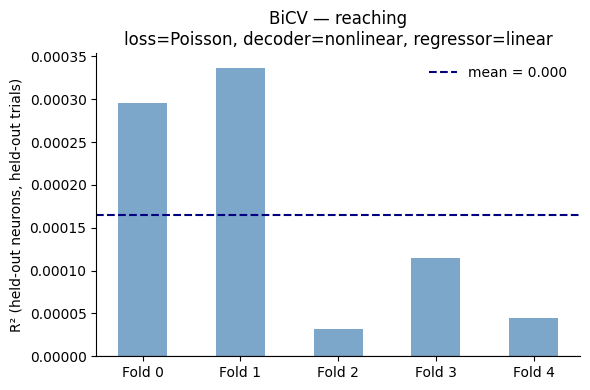

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(np.arange(n_folds), all_fold_r2, color="steelblue", alpha=0.7, width=0.5)
ax.axhline(np.mean(all_fold_r2), color="navy", lw=1.5, ls="--",
           label=f"mean = {np.mean(all_fold_r2):.3f}")
ax.set_xticks(np.arange(n_folds))
ax.set_xticklabels([f"Fold {i}" for i in range(n_folds)])
ax.set_ylabel("R² (held-out neurons, held-out trials)")
ax.set_title(
    f"BiCV — reaching\n"
    f"loss={LOSS_FUNC}, decoder={DECODER_TYPE}, regressor={REGRESSOR}"
)
ax.axhline(0, color="black", lw=0.8, ls="-")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(
    os.path.join(EXPERIMENT_PATH, f"bcv_r2_{DECODER_TYPE}_{REGRESSOR}.pdf"),
    bbox_inches="tight",
)
plt.show()